# Traffic Death Analysis

In this exercise, we will be analyzing the effect of alcohol taxes on traffic death in the United States.  The data set used in this exercise, `fatalities.csv`, is a state-year panel dataset (meaning it includes data on multiple states, and the data includes several years of data for each state. The data contains 336 observations on 34 variables. The variables used in the exercise are defined as follows:

`state`: factor variable indicating states

`year`: factor variable indicating years

`beertax`: numeric variable, Tax on the case of beer

In these exercises, we'll be looking at how beer taxes (which are believed to reduce alcohol consumption, potentially reducing drunk driving deaths) impact car accident fatality rates. 

More specifically, though, we'll be approaching our estimation of the impact of beer taxes in a few different ways in an effort to give you more of an intuitive sense of what happens when you add fixed effects to a regression. 



## Gradescope Autograding

Please follow [all standard guidance](https://www.practicaldatascience.org/ids720_specific/autograder_guidelines.html) for submitting this assignment to the Gradescope autograder, including storing your solutions in a dictionary called `results` and ensuring your notebook runs from the start to completion without any errors.

For this assignment, please name your file `exercise_panel.ipynb` before uploading.

You can check that you have answers for all questions in your `results` dictionary with this code:

```python
assert set(results.keys()) == {
    "ex1_num_states",
    "ex1_num_years",
    "ex2_avg_fatality_rate",
    "ex4_pooled_beta",
    "ex5_statefe_beta",
    "ex6_demeaned_beta",
    "ex7_panelols_beta",
    "ex7_panelols_se",
    "ex8_twfe_beta",
}
```

### Submission Limits

Please remember that you are **only allowed THREE submissions to the autograder.** Your last submission (if you submit 3 or fewer times), or your third submission (if you submit more than 3 times) will determine your grade Submissions that error out will **not** count against this total.

In [134]:
import pandas as pd
import numpy as np


## Exercise 1

Download and load the data from [this link](https://github.com/nickeubank/MIDS_Data/blob/master/UDS_arrest_data.csv), or by going to [http://www.github.com/nickeubank/MIDS_Data/](http://www.github.com/nickeubank/MIDS_Data/) and downloading the `us_driving_fatalities.csv` dataset. 

How many states does this dataset contain? What's the time frame of this dataset? (From which year to which year). And what constitutes a single observation (i.e. what is the unit of analysis for each row of the data?)

Store the number of states in `"ex1_num_states"` and number of years in `"ex1_num_years"`

In [135]:
url = "https://github.com/nickeubank/MIDS_Data/raw/refs/heads/master/us_driving_fatalities.csv"
data = pd.read_csv(url)
data.head()

,Unnamed: 0,state,year,spirits,unemp,income,emppop,beertax,baptist,mormon,...,nfatal2124,afatal,pop,pop1517,pop1820,pop2124,milestot,unempus,emppopus,gsp
0,1,al,1982,1.37,14.4,10544.152344,50.692039,1.539379,30.355700,0.32829,...,32,309.437988,3942002.25,208999.593750,221553.43750,290000.06250,28516.0,9.7,57.799999,-0.022125
1,2,al,1983,1.36,13.7,10732.797852,52.147030,1.788991,30.333599,0.34341,...,35,341.834015,3960008.00,202000.078125,219125.46875,290000.15625,31032.0,9.6,57.900002,0.046558
2,3,al,1984,1.32,11.1,11108.791016,54.168087,1.714286,30.311501,0.35924,...,34,304.872009,3988991.75,196999.968750,216724.09375,288000.15625,32961.0,7.5,59.500004,0.062798
3,4,al,1985,1.28,8.9,11332.626953,55.271137,1.652542,30.289499,0.37579,...,45,276.742004,4021007.75,194999.734375,214349.03125,284000.31250,35091.0,7.2,60.100002,0.027490
4,5,al,1986,1.23,9.8,11661.506836,56.514496,1.609907,30.267401,0.39311,...,29,360.716003,4049993.75,203999.890625,212000.00000,263000.28125,36259.0,7.0,60.700001,0.032143


In [136]:
results = {}
num_states = len(np.unique(data["state"]))
num_years = len(np.unique(data["year"]))
results["ex1_num_states"] = num_states
results["ex1_num_years"] = num_years
print("Number of years:", num_years)
print("Number of states:", num_states)

Number of years: 7
Number of states: 48


**There are 48 states and 7 years represented. A single observation is for a state and year.**

## Exercise 2

We use the fatality rate per 10,000 as the dependent variable, which you can compute using total fatalities(`fatal`) and population (`pop`). Note that because `pop` is often the name of a method in Python, you may have to navigate around some issues.

Please store the average fatality rate per 10_000 in for the dataset in `"ex2_avg_fatality_rate"`.

In [137]:
data["fatality_rate"] = (data["fatal"] / data["pop"]) * 10000
results["ex2_avg_fatality_rate"] = data["fatality_rate"].mean()
results["ex2_avg_fatality_rate"]

np.float64(2.040443784423569)

## Exercise 3

Draw a scatter plot using `beertax` as the x-axis, and `fat_rate` as the y-axis. Draw a fitted line showing the correlation between these two variables

Text(0, 0.5, 'Fatality Rate (per 10000)')

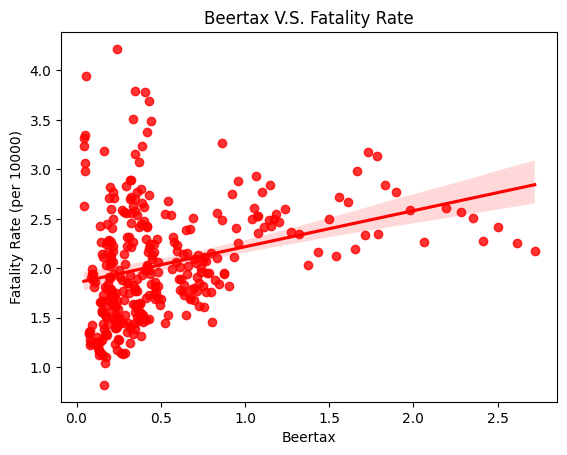

In [138]:
import matplotlib.pyplot as plt
import seaborn as sns

# plt.scatter(data['beertax'], data['fatality_rate'])
sns.regplot(
    data=data, x=data["beertax"], y=data["fatality_rate"], color="r", fit_reg=True
)
plt.title("Beertax V.S. Fatality Rate")
plt.xlabel("Beertax")
plt.ylabel("Fatality Rate (per 10000)")

## Exercise 4

Fit a simple OLS regression. This is sometimes called a "pooled" regression because we're "pooling" observations from different years into a single regression with no consideration of the time structure. 

Store the coefficient on beer tax in `"ex4_pooled_beta"`.

What do your results imply about the relationship between Beer Taxes and fatalities?

\begin{align*}
FatalityRate_i = \beta_0 + \beta_1 \times BeerTax_i
\end{align*}

In [139]:
import statsmodels.formula.api as smf

lm = smf.ols("fatality_rate ~ beertax", data=data).fit()
print(lm.summary())
beertax_coef = lm.params["beertax"]
print("Beer tax coefficient:", beertax_coef)
results["ex4_pooled_beta"] = beertax_coef

                            OLS Regression Results                            
Dep. Variable:          fatality_rate   R-squared:                       0.093
Model:                            OLS   Adj. R-squared:                  0.091
Method:                 Least Squares   F-statistic:                     34.39
Date:                Fri, 27 Feb 2026   Prob (F-statistic):           1.08e-08
Time:                        01:36:04   Log-Likelihood:                -271.04
No. Observations:                 336   AIC:                             546.1
Df Residuals:                     334   BIC:                             553.7
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      1.8533      0.044     42.539      0.0

**The coefficient on beer tax is 0.3646 which means for every increase in unit in beer tax, the fatality rate increases by 0.3646 (in ten thousands). This implies a positive relationship between beer taxes and fatalities.**

## Exercise 5

Now estimate your model again, this time adding state fixed effects (using the `C()` notation and your normal linear model machinery). What does this result imply about the relationship between beer taxes and fatalities?

Store the coefficient under `"ex5_statefe_beta"`



In [140]:
data["state"] = data["state"].astype("category")
lm_fe = smf.ols("fatality_rate ~ beertax + C(state)", data=data).fit()
print(lm_fe.summary())
beertax_fe_coef = lm_fe.params["beertax"]
print("Beer tax coefficient:", beertax_fe_coef)
results["ex5_statefe_beta"] = beertax_fe_coef

                            OLS Regression Results                            
Dep. Variable:          fatality_rate   R-squared:                       0.905
Model:                            OLS   Adj. R-squared:                  0.889
Method:                 Least Squares   F-statistic:                     56.97
Date:                Fri, 27 Feb 2026   Prob (F-statistic):          1.96e-120
Time:                        01:36:04   Log-Likelihood:                 107.97
No. Observations:                 336   AIC:                            -117.9
Df Residuals:                     287   BIC:                             69.09
Df Model:                          48                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept          3.4776      0.313     11.

**Now after using the fixed effects for state, the relationship between beer taxes and fatalities is negative as shown by the coefficient of beer taxes being roughly -0.656, meaning for every increase in 1 unit in beer tax, the fatality rate is decreasing by 0.656 (per ten thousands), holding constant all time-invariant state characteristics.**

## Exercise 6

Explain whey your results in Exercises 4 (without fixed effects) and Exercise 5 (with state fixed effects) look so different. What does this imply about states with high beer taxes?

**The results allow us to control for state level effects and focus on explaining intra state variation. So the state differences go away and we compare the effect within states. This shows that the states with higher beer taxes might have higher fatality rates for other reasons and that may be affecting the overall correlation. This makes sense because high tax states might be more urban in general and possibly have more traffic, and could therefore just have higher fatality rates, which could cause the beer coefficient to be higher.**

## Fixed Effects by Demeaning

Rather than just add indicator variables, we'll now use a different strategy for estimating fixed effects called an "entity-demeaning." This method is more computationally efficient, and can also help you understand how fixed effects work. 

Let's begin by assuming we want to estimate the following fixed-effect model:

\begin{align}
FatalityRate_{it} = \alpha + \beta BeerTax_{it} + \Psi Z_i + \epsilon_{it} \tag{1}
\end{align}

Where $FatalityRate_{it}$ is the fatality rate of state $i$ in year $t$, $\beta BeerTax_{it}$ is the beer tax of state $i$ in year $t$. $Z_i$ is a state fixed effect.

Rather than adding indicator variables, however, we'll use entity-demean as follows: 

First, we take the average on both sides of the regression. Here $n$ is the number of periods. 

\begin{align*}
\frac{1}{n} \sum_{i=1}^n FatalityRate_{it} =&  \,\alpha+ \beta_1 \frac{1}{n} \sum_{i=1}^n BeerTax_{it} + \Psi \frac{1}{n} \sum_{i=1}^n Z_i + \frac{1}{n} \sum_{i=1}^n \epsilon_{it} \\
\overline{FatalityRate}_i =& \,\alpha+ \beta_1 \overline{BeerTax}_i + \Psi  Z_i + \overline{\epsilon}_i.  \tag{2}
\end{align*}

Substracting the  from the main equation yields:

\begin{align*}
FatalityRate_{it} - \overline{FatalityRate}_i =& \, \beta_1(BeerTax_{it}-\overline{BeerTax}_i) + \Psi (Z_i - Z_i) + (\epsilon_{it} - \overline{\epsilon}_i)  \\
\overset{\sim}{FatalityRate}_{it} =& \, \beta_1 \overset{\sim}{BeerTax}_{it} + \overset{\sim}{\epsilon}_{it}  \tag{3}
\end{align*}

Where the $\sim$ means values have been demeaned by group. 

By taking the difference between the value of each observation (state-year) and the mean value of the entity (state) over n periods, we analyze how the within-state variation of beer tax affects that of the fatality rate. Moreover, by doing so we no longer need to estimate the fixed effects of $Z_i$, saving computing power if we are working on a dataset with a large number of fixed effects.

## Exercise 6

Implement the above entity-demeaned approach to estimate the fixed-effects model by hand (use basic functions, not full tools like `PanelOLS` or `C()` notation in `python`).

Compare your answer to the answer you got in Ex 5.

In [141]:
import statsmodels.api as sm

# add column for mean beer tax rate of state
data["Beer Tax State Mean"] = data.groupby("state")["beertax"].transform("mean")
data["Fatality Rate Mean"] = data.groupby("state")["fatality_rate"].transform("mean")
data["Fatality Rate Demean"] = data["fatality_rate"] - data["Fatality Rate Mean"]
data["Beertax Demean"] = data["beertax"] - data["Beer Tax State Mean"]

X = data["Beertax Demean"]
y = data["Fatality Rate Demean"]

model_dm = sm.OLS(y, X).fit()

results["ex6_demeaned_beta"] = model_dm.params["Beertax Demean"]

print(model_dm.summary())

                                  OLS Regression Results                                 
Dep. Variable:     Fatality Rate Demean   R-squared (uncentered):                   0.041
Model:                              OLS   Adj. R-squared (uncentered):              0.038
Method:                   Least Squares   F-statistic:                              14.23
Date:                  Fri, 27 Feb 2026   Prob (F-statistic):                    0.000191
Time:                          01:36:04   Log-Likelihood:                          107.97
No. Observations:                   336   AIC:                                     -213.9
Df Residuals:                       335   BIC:                                     -210.1
Df Model:                             1                                                  
Covariance Type:              nonrobust                                                  
                     coef    std err          t      P>|t|      [0.025      0.975]
-----------------

In [142]:
print("Exercise 6 Entity demeaned estimate:", results["ex6_demeaned_beta"])
print("Exercise 5 Fixed Effects estimate:", results["ex5_statefe_beta"])

Exercise 6 Entity demeaned estimate: -0.655873722150434
Exercise 5 Fixed Effects estimate: -0.6558737221504427


**The estimates from both approaches are nearly the same/identical, both roughly -0.65587. This has the same interpretation such that per unit increase in beertax the fatality rate decreases by 0.655, holding constant all time-invariant state characteristics.**

## Exercise 7 

Fit the model with state fixed-effect using `PanelOLS` / `lfe`. Note that PanelOLS automatically clusters standard errors when you add `EntityEffects` (unlike statsmodel's OLS function).

Compare it to your by-hand output. Store your coefficient in `"ex7_panelols_beta"` and your standard error `"ex7_panelols_se"`.

Interpret the result, including standard errors.

In [143]:
# !pip install linearmodels

In [144]:
from linearmodels import PanelOLS

data_indexed = data.copy()
data_indexed = data_indexed.set_index(["state", "year"])
panel_fit = PanelOLS(
    data_indexed["fatality_rate"], data_indexed[["beertax"]], entity_effects=True
).fit()
results["ex7_panelols_se"] = panel_fit.std_errors["beertax"]
results["ex7_panelols_beta"] = panel_fit.params["beertax"]
panel_fit

Dep. Variable:,fatality_rate,R-squared:,0.0407
Estimator:,PanelOLS,R-squared (Between):,-0.3805
No. Observations:,336,R-squared (Within):,0.0407
Date:,"Fri, Feb 27 2026",R-squared (Overall):,-0.3775
Time:,01:36:04,Log-likelihood,107.97
Cov. Estimator:,Unadjusted,,
,,F-statistic:,12.190
Entities:,48,P-value,0.0006
Avg Obs:,7.0000,Distribution:,"F(1,287)"
Min Obs:,7.0000,,
Max Obs:,7.0000,F-statistic (robust):,12.190


In [145]:
print(
    "With panel fit OLS, the estimate is ",
    panel_fit.params["beertax"],
    "which is nearly identical to exercises 6 and 7",
)

With panel fit OLS, the estimate is  -0.6558737221504338 which is nearly identical to exercises 6 and 7


**This has the same interpretation as above such that per unit increase in beertax the fatality rate decreases by 0.655, holding constant all time-invariant state characteristics.**

## Exercise 8

Now (using `PanelOLS`) estimate a fixed effects model using the following specification. Add fixed effects for **both** the state and the year, as well as the other covariates you think are important $X_{it}$). 

(Note: you may want to make sure `PanelOLS` adds an intercept to aid in interpretation of controls if you include categorical variables. If you use `PanelOLS.from_formula()`, just put a `1+` in after the `~`, or add a column of 1s to your X matrix if you're working with numpy arrays.)

Explain (a) the type of phenomenon we control for by adding `year` fixed effects, and (b) your choice of covariates. 

Put your beer tax coefficient in `"ex8_twfe_beta"`.

Interpret the result.

\begin{align}
FatalityRate_{it} = \alpha + \beta BeerTax_{it} + X_{it} + State_i + Year_t + \epsilon_{it}
\end{align}

In [146]:
data.columns

Index(['Unnamed: 0', 'state', 'year', 'spirits', 'unemp', 'income', 'emppop',
       'beertax', 'baptist', 'mormon', 'drinkage', 'dry', 'youngdrivers',
       'miles', 'breath', 'jail', 'service', 'fatal', 'nfatal', 'sfatal',
       'fatal1517', 'nfatal1517', 'fatal1820', 'nfatal1820', 'fatal2124',
       'nfatal2124', 'afatal', 'pop', 'pop1517', 'pop1820', 'pop2124',
       'milestot', 'unempus', 'emppopus', 'gsp', 'fatality_rate',
       'Beer Tax State Mean', 'Fatality Rate Mean', 'Fatality Rate Demean',
       'Beertax Demean'],
      dtype='str')

In [147]:
data["youngdrivers"]

0      0.211572
1      0.210768
2      0.211484
3      0.211140
4      0.213400
         ...   
331    0.208333
332    0.191962
333    0.168026
334    0.149312
335    0.131242
Name: youngdrivers, Length: 336, dtype: float64

In [148]:
panel_fit_q8 = PanelOLS(
    data_indexed["fatality_rate"],
    data_indexed[["beertax"]],
    entity_effects=True,
    time_effects=True,
).fit()
results["ex8_twfe_beta"] = panel_fit_q8.params["beertax"]
panel_fit_q8

Dep. Variable:,fatality_rate,R-squared:,0.0361
Estimator:,PanelOLS,R-squared (Between):,-0.3701
No. Observations:,336,R-squared (Within):,0.0407
Date:,"Fri, Feb 27 2026",R-squared (Overall):,-0.3672
Time:,01:36:05,Log-likelihood,115.04
Cov. Estimator:,Unadjusted,,
,,F-statistic:,10.513
Entities:,48,P-value,0.0013
Avg Obs:,7.0000,Distribution:,"F(1,281)"
Min Obs:,7.0000,,
Max Obs:,7.0000,F-statistic (robust):,10.513




**Adding youngdrivers could be interesting because within certain states, there could be more younger drivers/teens getting in car accidents or more dangerous things occurring if in big cities for example, so it could be worth looking at within states. If states that increase beer taxes also happen to have changes in their young driver population (such as opening up a new college or recent shifts in young people moving). then the beer tax coefficient could be partially capturing this effect of changes in young drivers instead of just the pure effect of beer tax.**


**Once controlling for inluding state and year fixed effects, the coefficient for beertax changes so that per unit increase in beertax the fatality rate decreases to 0.6399, holding constant all time-invariant state characteristics and common year shocks. This coefficient decreased slightly which means that after accounting for time and state the effect of beer tax was slightly less strong.**

In [149]:
results

{'ex1_num_states': 48,
 'ex1_num_years': 7,
 'ex2_avg_fatality_rate': np.float64(2.040443784423569),
 'ex4_pooled_beta': np.float64(0.36460544036774145),
 'ex5_statefe_beta': np.float64(-0.6558737221504427),
 'ex6_demeaned_beta': np.float64(-0.655873722150434),
 'ex7_panelols_se': np.float64(0.18784999357615312),
 'ex7_panelols_beta': np.float64(-0.6558737221504338),
 'ex8_twfe_beta': np.float64(-0.6399799857068713)}

In [150]:
assert set(results.keys()) == {
    "ex1_num_states",
    "ex1_num_years",
    "ex2_avg_fatality_rate",
    "ex4_pooled_beta",
    "ex5_statefe_beta",
    "ex6_demeaned_beta",
    "ex7_panelols_beta",
    "ex7_panelols_se",
    "ex8_twfe_beta",
}